In [2]:
from itertools import product

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
from matplotlib.lines import Line2D
from pytensor.ifelse import ifelse
from scipy import stats
from tqdm.auto import tqdm

In [3]:
az.style.use("arviz-whitegrid")
CORES = 4

Let pandemic intensity $X$ be a random variable defined by the following cumulative distribution function:

$$
\mathrm{F_X}(x; p_0, \xi, \sigma) = \begin{cases}
     1 - p_0 & x < \mu \\
        1 - p_0\left(1+\xi\dfrac{x-\mu}{\sigma}\right)^{-1/\xi} & x \geq \mu
\end{cases}
$$

where $p_0$ is the annual probability that an epidemic emerges and $\xi$, $\mu$ and $\sigma$ are the shape, location, and scale parameters of a generalized Pareto distribution (GPD) representing pandemic intensity conditional on arrival. For simplicity we will henceforth denote $F_X(x;p_0, \xi, \sigma)$ as $F_X$.

The CEPI expert survey does not provide any information with which to calibrate our pandemic intensity prior distribution. We therefore adopt the common reference prior:

$$\pi(\xi, \theta, \lambda) \propto (1 + \xi)^{-1} \cdot \theta^{-1} \cdot \sqrt{\frac{1-p}{p}}$$

where $\theta = (1 + \xi)\cdot \sigma$.

Reference priors are attractive because "they let the data speak as much as possible." Formally, they maximize the expected Kullback-Leibler divergence between the prior and posterior (see [here](https://projecteuclid.org/journals/annals-of-statistics/volume-37/issue-2/The-formal-definition-of-reference-priors/10.1214/07-AOS587.full) for more).

The reparametrization in terms of $\theta$ is key. It yields a Fisher information matrix that guarantees the existence of a "common reference prior", i.e., one that is invariant to the sequence in which one conducts a marginalization procedure used in reference prior construction (see [Berger, Bernardo and Sun (2015)](https://projecteuclid.org/journals/bayesian-analysis/volume-10/issue-1/Overall-Objective-Priors/10.1214/14-BA915.full)). A derivation of the GPD common reference prior using this parametrization can be found in [Kang, Kim, and Lee (2013)](https://koreascience.or.kr/article/JAKO201306735656489.pdf). I posit that it is trivial to show that adding in arrival rate $p_0$ yields the same reference prior scaled by the Jeffrey's prior for $p_0$.


One downside of reference priors is that they are vulnerable to causing MCMC chains to diverge off into funnels when parameters yield extremes values in the prior. For our prior, this is more likely to occur when $\xi \to -1$ and $\theta \to 0$. We also run into issues as $\xi \to 0$, due to the $1 + \frac{1}{\xi}$ term in the likelihood function.

To tame this behavior, I've tried to implement [softplus functions](https://pytorch.org/docs/stable/generated/torch.nn.Softplus.html) that nudge the chain in the opposite direction at the very extremes. For $\xi$, I have more aggressively restricted its domain to $(0.1, \infty)$. We can justify this prior if we use the [Cirillo and Taleb log transformation](https://www.nature.com/articles/s41567-020-0921-x).

Another downside of the reference prior approach is that it's not analytically tractable if we wanted to add truncation from above in the form of $F_{\bar{u}}(x) = \frac{F(x)}{F(\bar{u})}$ as we have done before. Instead, we either have to use [Cirillo and Taleb's log transformation](https://www.nature.com/articles/s41567-020-0921-x) or sharp ex post truncation.

In [4]:
# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")
intensity_data = final_allrisk_ds.set_index('year_start')['intensity']

# Fill in zeros for years with no observations.
all_years = pd.Series(range(1900, 2023 + 1))
intensity_data = intensity_data.reindex(all_years, fill_value=0)

In [5]:
THRESHOLD = 0.01

In [29]:
rng = np.random.default_rng(123)

# ---------------------------------------------------------------------------
# 1.  Posterior (reference prior + likelihood)
# ---------------------------------------------------------------------------
def log_posterior(params, y, thresh, xi_margin=0.5, sigma_floor=1e-4):
    """
    params = (xi, sigma, p)  -- natural parameter space
    """
    xi, sigma, p = params
    
    # ----- HARD SUPPORT CHECKS ------------------------------------------------
    if xi <= -1 + xi_margin:      # ensures ξ > –1 + margin
        return -np.inf
    if sigma <= sigma_floor:
        return -np.inf
    if p <= 0 or p >= 1:
        return -np.inf
    
    # -------------------------------------------------------------------------
    # reference prior π(ξ,σ,p) ∝ (1+ξ)^-1 σ^-1 [p(1-p)]^-½
    lp  = -np.log1p(xi)           # (1+ξ)^-1
    lp += -np.log(sigma) - np.log1p(xi)              # theta^-1
    lp += -0.5 * np.log(p*(1-p))  # Beta(½,½) on p
    
    # -------------------------------------------------------------------------
    is_tail = y > thresh
    tail_excess = y[is_tail] - thresh
    lp += np.sum(np.log(1 - p) * (~is_tail))
    lp += np.sum(np.log(p) + stats.genpareto.logpdf(tail_excess, c=xi, scale=sigma))
    
    return lp

# ---------------------------------------------------------------------------
# 2.  Random-walk Metropolis sampler with hard rejection
# ---------------------------------------------------------------------------
def sample_rw_mh(y, thresh, sample_n=40_000, burn=10_000,
                 step=(0.05, 0.05, 0.01),
                 init=(0.1, 1.0, 0.5)):
    """
    step  : proposal std-devs in (xi, sigma, p)
    """
    tot_n = sample_n + burn
    samples = np.empty((tot_n, 3))
    lp_cur  = log_posterior(init, y, thresh)
    cur     = np.array(init, dtype=float)
    acc = 0
    for t in tqdm(range(tot_n)):
        prop = rng.normal(cur, step)
        lp_prop = log_posterior(prop, y, thresh)
        if lp_prop - lp_cur > np.log(rng.random()):
            cur, lp_cur = prop, lp_prop
            if t >= burn:  # Only count acceptance after burn-in
                acc += 1
        samples[t] = cur
    accept_rate = acc / sample_n  # acc now only counts post burn-in acceptances
    print(f"⇢  Acceptance rate: {accept_rate:.3f}")
    return samples[burn:], accept_rate


In [39]:
# ---------------------------------------------------------------------------
# 3.  Run multiple chains in parallel ----------------------------------------
# ---------------------------------------------------------------------------
from multiprocessing import Pool
from functools import partial

# Different initial conditions
init_conditions = [
    (0.1, 1.0, 0.0),    # original
    (-0.1, 0.5, -1.0),  # different starting point
    (0.2, 2.0, 1.0),    # another variation
    (0.0, 1.5, 0.5),    # fourth chain
]

# Partial function with fixed parameters
sampler_partial = partial(sample_rw_mh, 
                         y=intensity_data, 
                         thresh=THRESHOLD,
                         n_iter=10_000,
                         burn=4_000,
                         step=(0.05, 0.05, 0.1))

# Run chains in parallel
# with Pool(processes=4) as pool:
#     results = pool.map(sampler_partial, init_conditions)

chains, acc_rates = sample_rw_mh(intensity_data, THRESHOLD, sample_n=10_000, burn=4_000, step=(1, 1, 0.5)) #zip(*results)
chains = np.array(chains)

print("\nAcceptance rates for each chain:")
if isinstance(acc_rates, (list, np.ndarray)):
    for i, rate in enumerate(acc_rates):
        print(f"Chain {i+1}: {rate:.3f}")
else:
    print(f"Chain 1: {acc_rates:.3f}")

# # Transform back to natural scale for all chains
# xi_samp = chains[:, :, 0].T
# sigma_samp = chains[:, :, 1].T
# logit_p_samp = chains[:, :, 2].T
# p_samp = 1 / (1 + np.exp(-logit_p_samp))
# theta_samp = sigma_samp * (1 + xi_samp)            # orthogonal θ

# # ---------------------------------------------------------------------------
# # 4.  Diagnostics with ArviZ --------------------------------------------------
# # ---------------------------------------------------------------------------
# idata = az.from_dict(
#     posterior={
#         "xi": xi_samp,
#         "sigma": sigma_samp,
#         "theta": theta_samp,
#         "p": p_samp,
#     }
# )

# display(az.summary(idata, var_names=["xi", "sigma", "p", "theta"]))
# az.plot_trace(idata, var_names=["xi","sigma","p"])
# plt.show()

# az.plot_autocorr(idata, var_names=["xi","sigma","p"], max_lag=100)
# plt.show()

# # Now R-hat is meaningful with multiple chains
# print("\nR-hat and ESS:")
# print(az.rhat(idata).to_dataframe())
# print("\nESS:", az.ess(idata, method='mean').to_dataframe())

# # Plot pairs with divergences
# az.plot_pair(
#     idata,
#     var_names=["xi", "sigma", "p", "theta"],
#     kind="hexbin",
#     divergences=True,
#     divergences_kwargs={"color":"r"}
# )
# plt.show()

  0%|          | 0/14000 [00:00<?, ?it/s]

⇢  Acceptance rate: 0.404

Acceptance rates for each chain:
Chain 1: 0.404


arviz - WARNING - Shape validation failed: input_shape: (1, 10000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
xi,3.314,4.337,-0.023,10.466,0.924,1.672,40.0,36.0,NaN
sigma,1.283,1.604,0.000,3.884,0.121,0.099,42.0,85.0,NaN
p,0.045,0.019,0.013,0.079,0.001,0.000,775.0,1366.0,NaN
theta,2.907,3.322,0.001,8.029,0.273,0.221,48.0,116.0,NaN


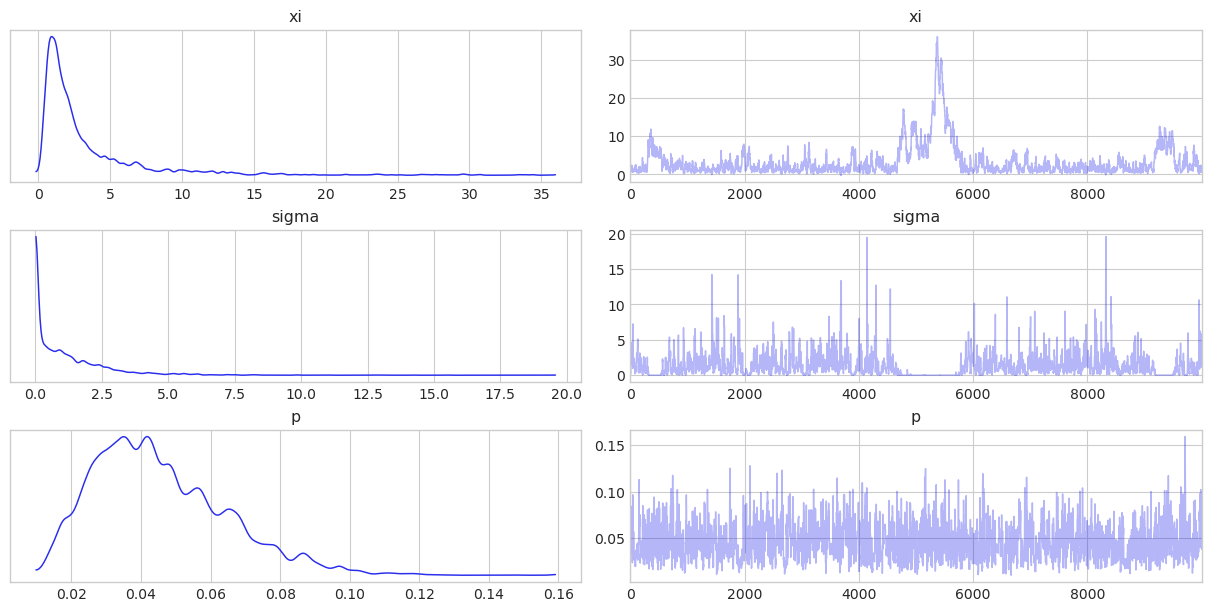

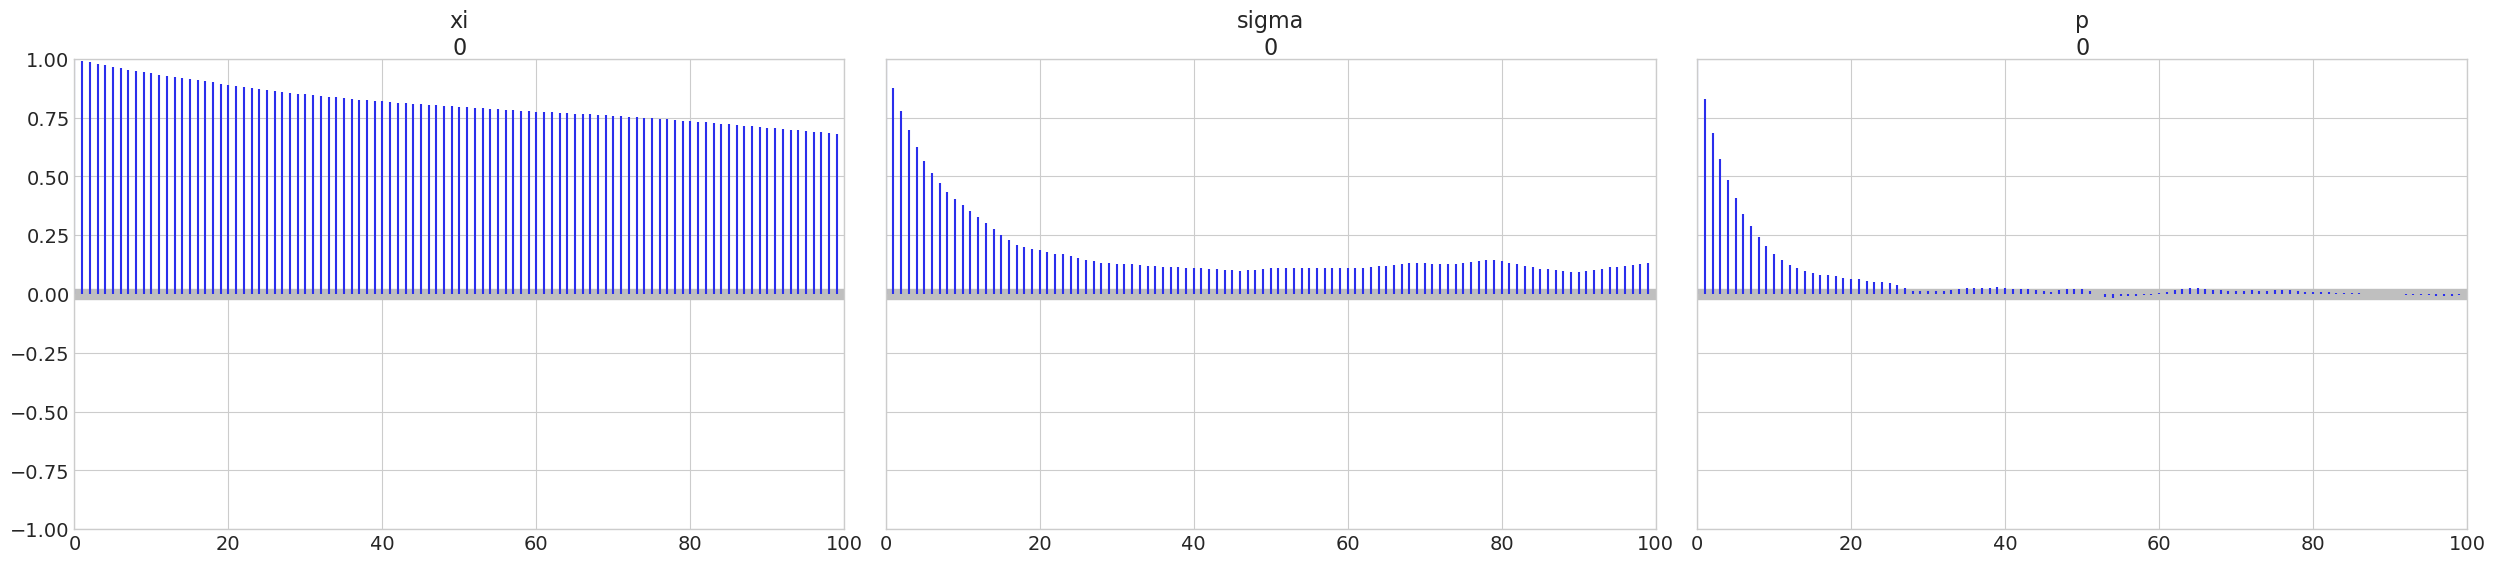


R-hat and ESS:


ValueError: no valid index for a 0-dimensional object

In [41]:
# Transform back to natural scale for all chains
xi_samp = chains[:, 0].T
sigma_samp = np.exp(chains[:, 1].T)
logit_p_samp = chains[:, 2].T
p_samp = 1 / (1 + np.exp(-logit_p_samp))
theta_samp = sigma_samp * (1 + xi_samp)            # orthogonal θ

# ---------------------------------------------------------------------------
# 4.  Diagnostics with ArviZ --------------------------------------------------
# ---------------------------------------------------------------------------
idata = az.from_dict(
    posterior={
        "xi": xi_samp,
        "sigma": sigma_samp,
        "theta": theta_samp,
        "p": p_samp,
    }
)

display(az.summary(idata, var_names=["xi", "sigma", "p", "theta"]))
az.plot_trace(idata, var_names=["xi","sigma","p"])
plt.show()

az.plot_autocorr(idata, var_names=["xi","sigma","p"], max_lag=100)
plt.show()

# Now R-hat is meaningful with multiple chains
print("\nR-hat and ESS:")
print(az.rhat(idata).to_dataframe())
print("\nESS:", az.ess(idata, method='mean').to_dataframe())
